## MR4010 Navegacion autonoma

### SVM

### Paso 1 — Título del notebook

# MR4010 Navegación Autónoma

## Detección de Vehículos con HOG y SVM

En este notebook se desarrolla un clasificador para detectar vehículos utilizando:

- HOG: Histogram of Oriented Gradients
- SVM: Support Vector Machine

El dataset está dividido en dos carpetas:

- `vehicles`
- `non-vehicles`

Dataset Vehicles https://s3.amazonaws.com/udacity-sdc/Vehicle_Tracking/vehicles.zip

Dataset NO Vehicles https://s3.amazonaws.com/udacity-sdc/Vehicle_Tracking/non-vehicles.zip


### Paso 2 — Cargar bibliotecas necesarias

In [46]:
# ============================================================
# PASO 2: IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# En este bloque se cargan las librerías necesarias para:
# - Leer imágenes
# - Procesar imágenes
# - Visualizar resultados
# - Extraer características HOG
# - Entrenar modelos de Machine Learning

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2

from skimage.feature import hog

### Paso 3 — Importar los datasets

In [47]:
# ============================================================
# PASO 3: IMPORTACIÓN DEL DATASET
# ============================================================
# El dataset está organizado en dos carpetas:
#
# data_svm/vehicles/
# data_svm/non-vehicles/
#
# glob permite buscar archivos automáticamente dentro
# de carpetas y subcarpetas.

import glob

vehicle = glob.glob(r"D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\data_svm\vehicles\vehicles\KITTI_extracted\*.png")
no_vehicle = glob.glob(r"D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\data_svm\non-vehicles\non-vehicles\GTI\*.png")

### Paso 4 — Verificar cantidad de imágenes

In [48]:
# ============================================================
# PASO 4: VERIFICAR CANTIDAD DE IMÁGENES
# ============================================================
# Se cuenta cuántas imágenes hay en cada clase.

len(vehicle)

5966

In [49]:
# Cantidad de imágenes sin vehículo

len(no_vehicle)

3900

### Paso 5 — Mostrar una imagen con vehículo

(64, 64, 3)


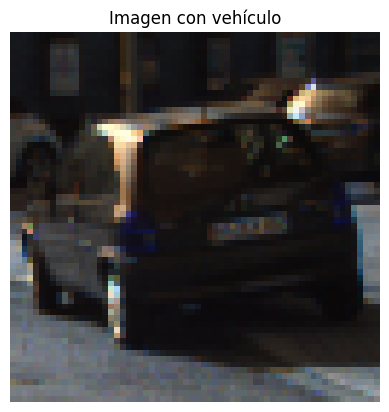

In [84]:
# ============================================================
# PASO 5: VISUALIZAR UNA IMAGEN CON VEHÍCULO
# ============================================================
# Se muestra una imagen ejemplo para validar que el dataset
# fue cargado correctamente.

img_color = cv2.imread(vehicle[10])
print(img_color.shape)
plt.imshow(img_color)
plt.title("Imagen con vehículo")
plt.axis("off")
plt.show()

### Paso 6 — Convertir imagen a escala de grises

(64, 64, 3)


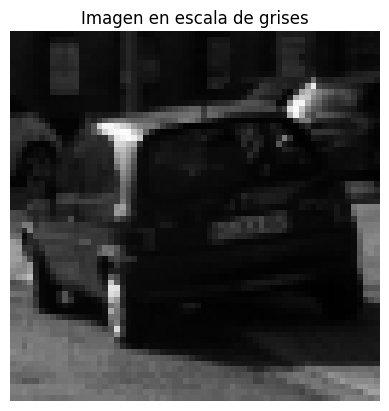

In [85]:
# ============================================================
# PASO 6: CONVERSIÓN A ESCALA DE GRISES
# ============================================================
# HOG trabaja con gradientes de intensidad.
# Por eso se convierte la imagen a grayscale.

img_gray = cv2.cvtColor(
    img_color,
    cv2.COLOR_BGR2GRAY
)
print(img_color.shape)
plt.imshow(img_gray, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

### Paso 7 — Calcular HOG de una imagen

In [52]:
# ============================================================
# PASO 7: CÁLCULO DEL DESCRIPTOR HOG
# ============================================================
# HOG extrae características relacionadas con:
# - Bordes
# - Gradientes
# - Formas
#
# Estas características se usan después para entrenar el SVM.

features, hog_img = hog(
    img_gray,
    orientations=11,
    pixels_per_cell=(16,16),
    cells_per_block=(2,2),
    transform_sqrt=False,
    visualize=True,
    feature_vector=True
)

### Paso 8 — Revisar dimensiones del HOG

In [53]:
# ============================================================
# PASO 8: REVISAR DIMENSIONES DEL VECTOR HOG
# ============================================================
# El vector HOG será la representación numérica de la imagen.

features.shape

(396,)

In [54]:
# Dimensiones de la imagen HOG para visualización

hog_img.shape

(64, 64)

### Paso 9 — Visualizar imagen HOG

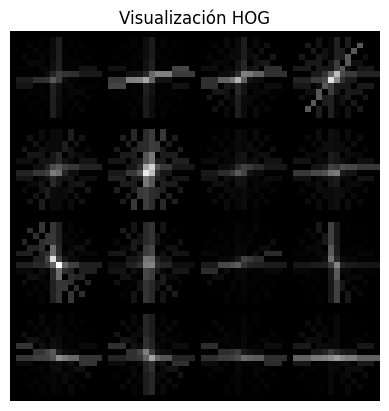

In [55]:
# ============================================================
# PASO 9: VISUALIZAR HOG
# ============================================================
# Esta imagen permite observar los gradientes principales
# detectados en la imagen original.

plt.imshow(hog_img, cmap="gray")
plt.title("Visualización HOG")
plt.axis("off")
plt.show()

### Paso 10 — Extraer HOG para imágenes con vehículos

In [56]:
# ============================================================
# PASO 10: EXTRAER FEATURES HOG PARA VEHÍCULOS
# ============================================================
# Se recorren todas las imágenes de la clase vehicle.
# Para cada imagen:
#   1. Se lee la imagen
#   2. Se convierte a grayscale
#   3. Se calculan las features HOG
#   4. Se guardan en una lista

vehicle_hog_accum = []

for i in vehicle:

    img_color = mpimg.imread(i)

    img_gray = cv2.cvtColor(
        img_color,
        cv2.COLOR_BGR2GRAY
    )

    vehicle_hog_feature, vehicle_hog_img = hog(
        img_gray,
        orientations=11,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        transform_sqrt=False,
        visualize=True,
        feature_vector=True
    )

    vehicle_hog_accum.append(vehicle_hog_feature)

### Paso 11 — Crear matriz X y vector y para vehículos

In [57]:
# ============================================================
# PASO 11: CREAR DATASET POSITIVO
# ============================================================
# X_vehicle contiene las features HOG de vehículos.
# y_vehicle contiene las etiquetas:
#
#   1 = vehículo

X_vehicle = np.vstack(vehicle_hog_accum).astype(np.float64)

y_vehicle = np.ones(len(X_vehicle))

In [58]:
# Verificar dimensiones de X_vehicle

X_vehicle.shape

(5966, 396)

In [59]:
# Verificar dimensiones de y_vehicle

y_vehicle.shape

(5966,)

### Paso 12 — Extraer HOG para imágenes sin vehículos

In [60]:
# ============================================================
# PASO 12: EXTRAER FEATURES HOG PARA NO VEHÍCULOS
# ============================================================
# Se repite el mismo proceso para las imágenes negativas:
#
#   0 = no vehículo

novehicle_hog_accum = []

for i in no_vehicle:

    img_color = mpimg.imread(i)

    img_gray = cv2.cvtColor(
        img_color,
        cv2.COLOR_BGR2GRAY
    )

    novehicle_hog_feature, novehicle_hog_img = hog(
        img_gray,
        orientations=11,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        transform_sqrt=False,
        visualize=True,
        feature_vector=True
    )

    novehicle_hog_accum.append(novehicle_hog_feature)

### Paso 13 — Crear matriz X y vector y para no vehículos

In [61]:
# ============================================================
# PASO 13: CREAR DATASET NEGATIVO
# ============================================================
# X_novehicle contiene las features HOG de imágenes sin vehículo.
# y_novehicle contiene las etiquetas:
#
#   0 = no vehículo

X_novehicle = np.vstack(novehicle_hog_accum).astype(np.float64)

y_novehicle = np.zeros(len(X_novehicle))

In [62]:
# Verificar dimensiones de X_novehicle

X_novehicle.shape

(3900, 396)

In [63]:
# Verificar dimensiones de y_novehicle

y_novehicle.shape

(3900,)

### Paso 14 — Combinar ambos datasets

In [64]:
# ============================================================
# PASO 14: COMBINAR DATASETS
# ============================================================
# Se combinan las imágenes positivas y negativas.
#
# X contiene todas las features.
# y contiene todas las etiquetas.

X = np.vstack((X_vehicle, X_novehicle))

X.shape

(9866, 396)

In [65]:
# Combinar etiquetas:
# 1 = vehículo
# 0 = no vehículo

y = np.hstack((y_vehicle, y_novehicle))

y.shape

(9866,)

### Paso 15 — Dividir datos en entrenamiento y prueba

In [66]:
# ============================================================
# PASO 15: DIVISIÓN TRAIN / TEST
# ============================================================
# Se utiliza 80% para entrenamiento y 20% para prueba.
#
# random_state=42 permite obtener los mismos resultados
# cada vez que se ejecuta el notebook.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
# Verificar tamaño del dataset de entrenamiento

X_train.shape

(7892, 396)

In [68]:
# Verificar tamaño del dataset de prueba

X_test.shape

(1974, 396)

### Paso 16 — Crear y entrenar el modelo SVC

In [69]:
# ============================================================
# PASO 16: ENTRENAMIENTO DEL MODELO SVM
# ============================================================
# Se utiliza SVC como clasificador.
#
# SVM busca encontrar una frontera de decisión que separe:
#   - vehículos
#   - no vehículos

from sklearn.svm import SVC

svc_model = SVC()

svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Paso 17 — Realizar predicciones

In [70]:
# ============================================================
# PASO 17: PREDICCIONES CON EL MODELO
# ============================================================
# Se utiliza el conjunto de prueba para evaluar el modelo.

y_predict = svc_model.predict(X_test)

### Paso 18 — Matriz de confusión

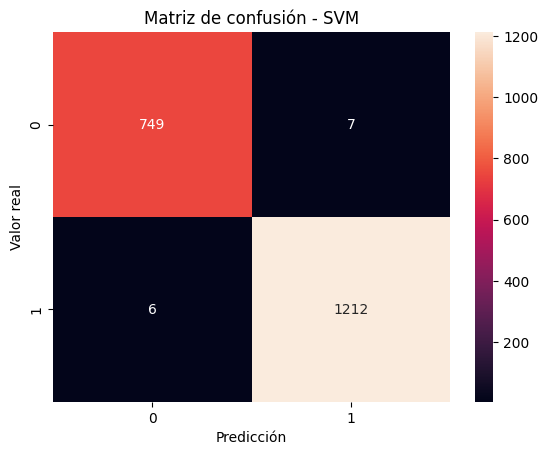

In [71]:
# ============================================================
# PASO 18: MATRIZ DE CONFUSIÓN
# ============================================================
# La matriz de confusión permite observar:
#
# - Verdaderos negativos
# - Falsos positivos
# - Falsos negativos
# - Verdaderos positivos

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, y_predict)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### Paso 19 — Reporte de clasificación

In [72]:
# ============================================================
# PASO 19: CLASSIFICATION REPORT
# ============================================================
# Este reporte muestra:
#
# precision:
#   Qué tan confiables son las predicciones positivas.
#
# recall:
#   Qué tanto logra detectar la clase real.
#
# f1-score:
#   Balance entre precision y recall.
#
# accuracy:
#   Porcentaje total de predicciones correctas.

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       756
         1.0       0.99      1.00      0.99      1218

    accuracy                           0.99      1974
   macro avg       0.99      0.99      0.99      1974
weighted avg       0.99      0.99      0.99      1974



### Paso 20 — Definir parámetros para GridSearchCV

In [73]:
# ============================================================
# PASO 20: GRID SEARCH CV - PARÁMETROS
# ============================================================
# Se definen diferentes valores para buscar la mejor
# combinación de hiperparámetros.
#
# C:
#   Controla qué tanto se penalizan errores.
#
# gamma:
#   Controla la influencia de cada punto de entrenamiento.
#
# kernel:
#   Define el tipo de frontera de decisión.

param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [1, 0.1, 0.01, 0.001, 0.0001],
    "kernel": ["rbf"]
}

### Paso 21 — Ejecutar GridSearchCV

In [74]:
# ============================================================
# PASO 21: ENTRENAMIENTO CON GRID SEARCH CV
# ============================================================
# GridSearchCV prueba varias combinaciones de parámetros
# y selecciona el mejor modelo.

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=4
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.984 total time=   3.6s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   3.4s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.984 total time=   3.3s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.984 total time=   3.2s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.986 total time=   2.7s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.975 total time=   1.4s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.982 total time=   1.3s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.986 total time=   1.2s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.987 total time=   1.4s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.985 total time=   1.3s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.958 total time=   3.6s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


### Paso 22 — Revisar mejores parámetros

In [75]:
# ============================================================
# PASO 22: MEJORES PARÁMETROS
# ============================================================
# Muestra la mejor combinación encontrada.

grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [76]:
# Muestra el mejor estimador encontrado.

grid.best_estimator_

,C,10
,kernel,'rbf'
,degree,3
,gamma,1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Paso 23 — Predicciones con el modelo optimizado

In [77]:
# ============================================================
# PASO 23: PREDICCIONES CON GRID SEARCH
# ============================================================
# Se evalúa el mejor modelo encontrado por GridSearchCV.

grid_predictions = grid.predict(X_test)

### Paso 24 — Matriz de confusión del modelo optimizado

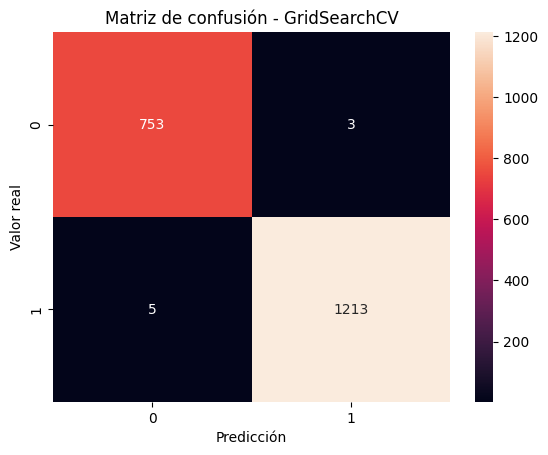

In [78]:
# ============================================================
# PASO 24: MATRIZ DE CONFUSIÓN DEL MODELO OPTIMIZADO
# ============================================================

cm = confusion_matrix(y_test, grid_predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de confusión - GridSearchCV")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### Paso 25 — Reporte final del modelo optimizado

In [79]:
# ============================================================
# PASO 25: REPORTE FINAL DEL MODELO OPTIMIZADO
# ============================================================

print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       756
         1.0       1.00      1.00      1.00      1218

    accuracy                           1.00      1974
   macro avg       1.00      1.00      1.00      1974
weighted avg       1.00      1.00      1.00      1974



### Paso 26 - Crear Modelo

In [80]:
# =========================================================
# GUARDAR MODELO ENTRENADO
# =========================================================

import pickle

model_path = r"D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\vehicle_svm_hog.pkl"

with open(model_path, "wb") as file:
    pickle.dump(grid.best_estimator_, file)

print("Modelo guardado en:")
print(model_path)

Modelo guardado en:
D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\models\vehicle_svm_hog.pkl


### Paso 27 — Conclusión

# Conclusión

En este notebook se implementó un clasificador clásico de visión computacional para detectar vehículos.

El flujo principal fue:

1. Cargar imágenes de vehículos y no vehículos.
2. Convertir las imágenes a escala de grises.
3. Extraer características usando HOG.
4. Crear las etiquetas de clasificación.
5. Entrenar un modelo SVM.
6. Evaluar el desempeño con matriz de confusión y classification report.
7. Optimizar el modelo con GridSearchCV.

La combinación HOG + SVM permite detectar patrones visuales asociados a la forma de un vehículo, como bordes, contornos y gradientes.

Este enfoque es importante en navegación autónoma porque representa una técnica clásica previa al uso extensivo de redes neuronales convolucionales.